# Clase 31 Agosto 2026

## Desplazamiento

In [86]:
import pandas as pd
df = pd.read_csv('Datasets/Salarios_minimos.csv')
df.describe()


,Periodo,Salario
count,34.000000,34.000000
mean,2002.177353,39.560588
std,9.117739,23.233915
min,1988.250000,8.000000
25%,1995.075000,16.830000
50%,2001.500000,41.250000
75%,2009.750000,56.795000
max,2018.000000,88.360000


In [87]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

df['Periodo Escalado'] = df['Periodo'] - 1988
df.head()



,Periodo,Salario,Periodo Escalado
0,1988.25,8.00,0.25
1,1989.00,8.64,1.00
2,1989.50,9.16,1.50
3,1990.00,10.08,2.00
4,1990.84,11.90,2.84


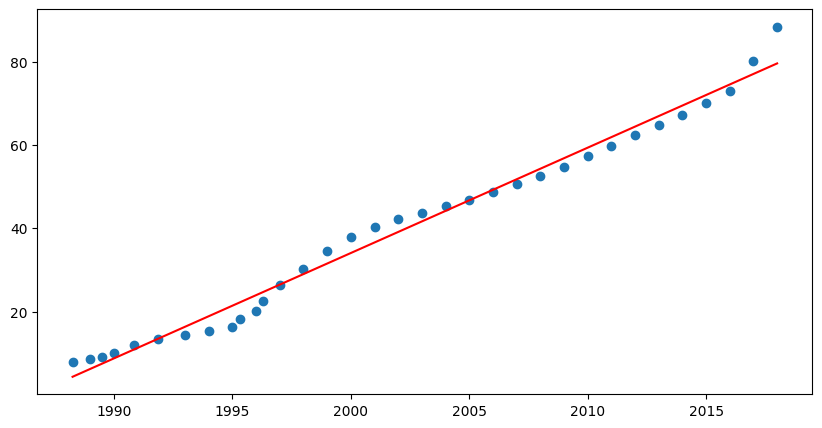

In [88]:
arr1 = np.reshape(df['Periodo Escalado'].values, (-1, 1))
lr = LinearRegression()
lr.fit(arr1, df['Salario'])
df['Prediccion Escalada'] = lr.predict(arr1)
plt.figure(figsize=(10, 5))
plt.scatter(df['Periodo Escalado'] + 1988, df['Salario'])
plt.plot(df['Periodo Escalado'] + 1988, df['Prediccion Escalada'], color='red')
plt.show()

In [89]:
arr2 = np.reshape(df['Periodo'].values, (-1, 1))
lr.fit(arr2, df['Salario'])
df['Prediccion'] = lr.predict(arr2)


error_prediciones = df['Prediccion'] - df['Prediccion Escalada']
print(error_prediciones.describe())

count    3.400000e+01
mean    -3.788865e-13
std      2.625543e-13
min     -8.242296e-13
25%     -5.808687e-13
50%     -3.801404e-13
75%     -1.740830e-13
max      4.263256e-14
dtype: float64


El desplazamiento no influye en las predicciones realizadas

## Escalamiento

### Min-Max

In [90]:
bt = pd.read_csv('Datasets/bateria_tableta.txt')
bt.describe()

,carga,duracion
count,100.000000,100.000000
mean,4.573000,6.206800
std,2.788603,2.454116
min,0.000000,0.000000
25%,1.987500,3.975000
50%,4.375000,8.000000
75%,6.522500,8.000000
max,11.720000,8.000000


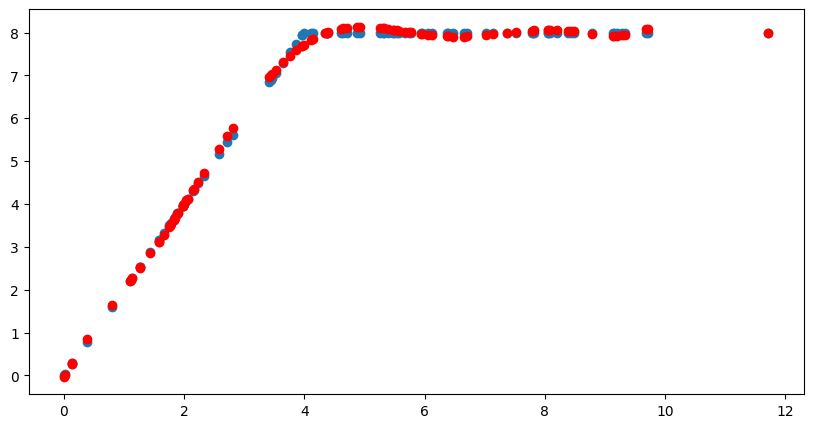

In [91]:
bt['carga_escalada'] = (bt['carga']/bt['carga'].max()) + 1
x1 = np.reshape(bt['carga_escalada'].values, (-1, 1))
x2 = x1**2
x3 = x1**3
x4 = x1**4
x5 = x1**5
x6 = x1**6
x7 = x1**7
x8 = x1**8
x9 = x1**9

arr2 = np.hstack((x1, x2, x3, x4, x5, x6, x7, x8, x9))
lr.fit(arr2, bt['duracion'])
bt['prediccion_escalada'] = lr.predict(arr2)
plt.figure(figsize=(10, 5))
plt.scatter((bt['carga_escalada']-1)*bt['carga'].max(), bt['duracion'])
plt.scatter((bt['carga_escalada']-1)*bt['carga'].max(), bt['prediccion_escalada'], color='red')
plt.show()


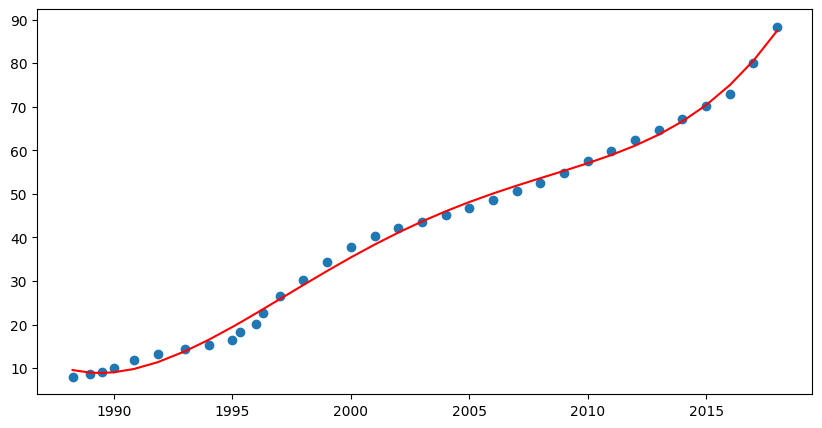

In [92]:
df['Periodo Escalado'] = (df['Periodo']/df['Periodo'].max()) + 1
x1 = np.reshape(df['Periodo Escalado'].values, (-1, 1))
x2 = x1**2
x3 = x1**3
x4 = x1**4
x5 = x1**5
x6 = x1**6
x7 = x1**7
x8 = x1**8
x9 = x1**9

arr3 = np.hstack((x1, x2, x3, x4, x5, x6, x7, x8, x9))
lr.fit(arr3, df['Salario'])
df['prediccion_escalada'] = lr.predict(arr3)
plt.figure(figsize=(10,5))
plt.scatter((df['Periodo Escalado']-1)*df['Periodo'].max(), df['Salario'])
plt.plot((df['Periodo Escalado']-1)*df['Periodo'].max(), df['prediccion_escalada'], color='red')
plt.show()

### Estándar

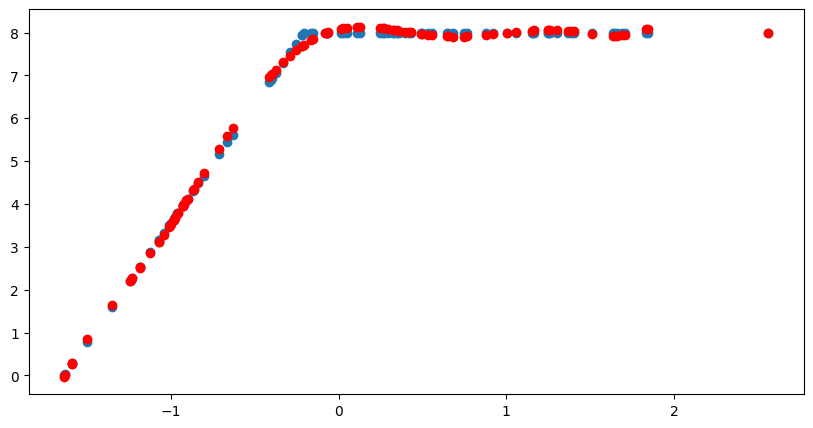

In [93]:
bt['carga_est'] = (bt['carga'] - bt['carga'].mean())/bt['carga'].std()
x1 = np.reshape(bt['carga_est'].values, (-1, 1))
x2 = x1**2
x3 = x1**3
x4 = x1**4
x5 = x1**5
x6 = x1**6
x7 = x1**7
x8 = x1**8
x9 = x1**9

arr_bt_est = np.hstack((x1, x2, x3, x4, x5, x6, x7, x8, x9))
lr.fit(arr_bt_est, bt['duracion'])
bt['prediccion_est'] = lr.predict(arr_bt_est)
plt.figure(figsize=(10, 5))
plt.scatter(bt['carga_est'], bt['duracion'])
plt.scatter(bt['carga_est'], bt['prediccion_est'], color='red')
plt.show()

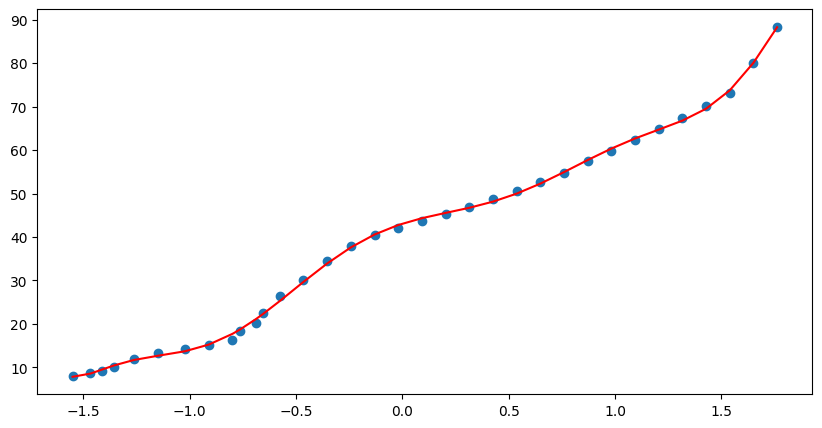

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df[['Periodo']])
df['periodo_est'] = scaler.transform(df[['Periodo']])
x1 = np.reshape(df['periodo_est'].values, (-1, 1))
x2 = x1**2
x3 = x1**3
x4 = x1**4
x5 = x1**5
x6 = x1**6
x7 = x1**7
x8 = x1**8
x9 = x1**9

arr_df_est = np.hstack((x1, x2, x3, x4, x5, x6, x7, x8, x9))
lr.fit(arr_df_est, df['Salario'])
df['prediccion_est'] = lr.predict(arr_df_est)
plt.figure(figsize=(10,5))
plt.scatter(df['periodo_est'], df['Salario'])
plt.plot(df['periodo_est'], df['prediccion_est'], color='red')
plt.show()

In [95]:
error_pred_df_est = np.sum((df['Salario'] - df['prediccion_est']) ** 2)
print(error_pred_df_est)

9.505034255313069
